# LCEL (LangChain Expression Language)
- LCEL은 LangChain에서 **체인(Chain)** 을 선언적으로 구성하기 위한 언어입니다.

### 주요 특징
- 선언적 구성: 작업의 순서와 흐름을 명시적으로 정의하여, 복잡한 로직을 간결하게 표현할 수 있습니다.
- 파이프 연산자(|) 지원: Unix의 파이프처럼, 함수의 출력을 다음 함수의 입력으로 전달하여 체인을 구성합니다.

> 코드 예제 
```ini
chain = prompt | llm | parser
```

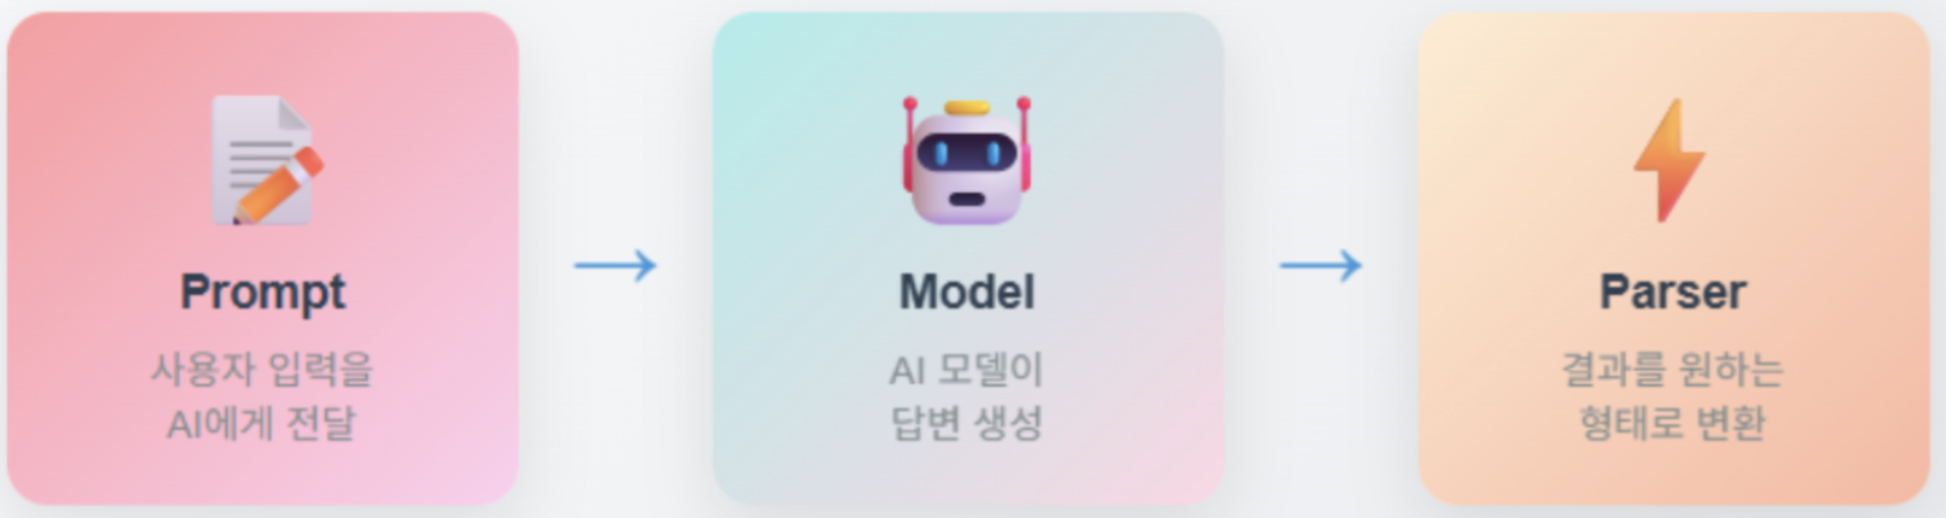

# 조건부 체인 (Conditional Chains)
- 입력에 따라 다른 체인을 실행할 수 있습니다.

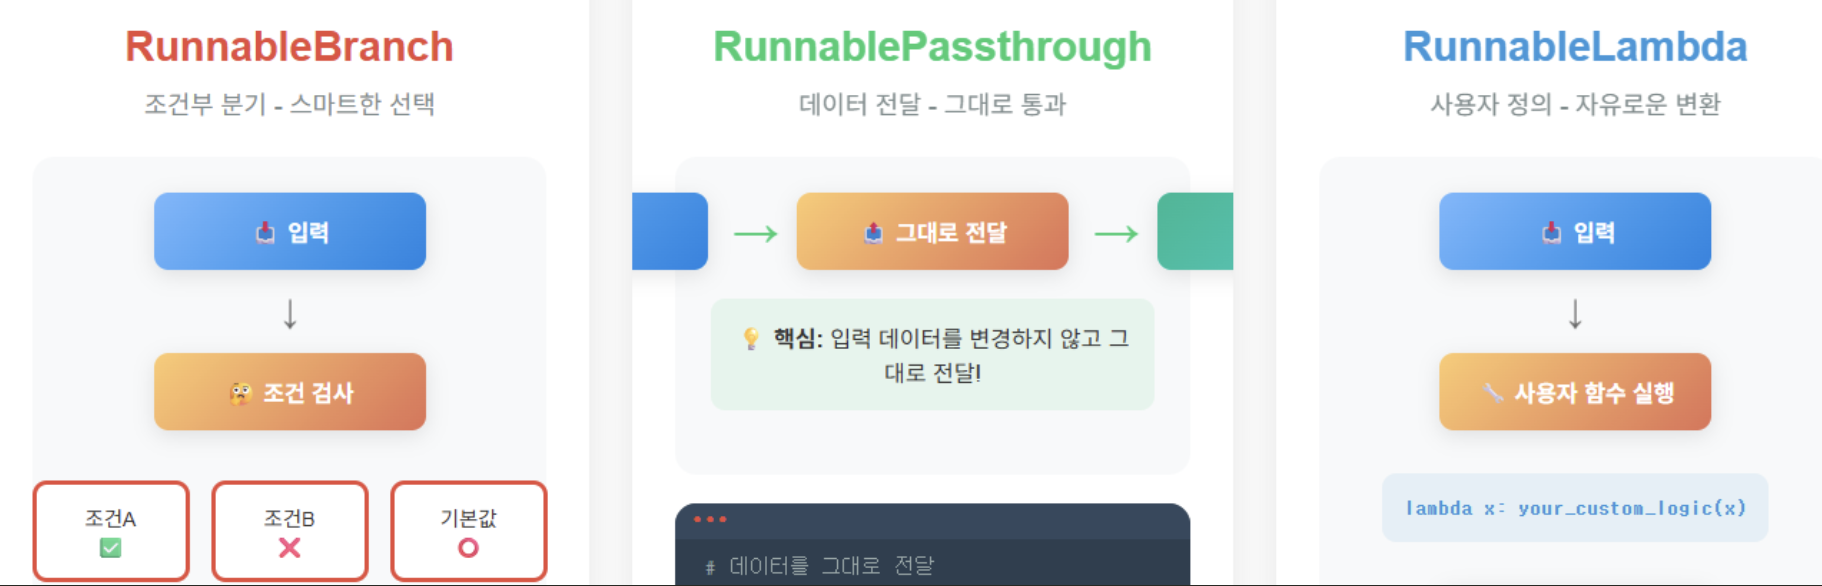

# Model

## [Groq API Key](https://console.groq.com/keys)

In [1]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

## LLM

In [2]:
from langchain_groq import ChatGroq

# 정확한 모델 (Precise Model)
# - temperature 낮음 (0.1): 일관되고 정확한 답변
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    model_kwargs={
        "top_p":1.0,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.0,         # 반복 억제
        "presence_penalty":0.0,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

# Parser

In [3]:
from langchain_core.output_parsers import StrOutputParser

# OutputParser 설정
output_parser = StrOutputParser()

# RunnablePassthrough

## 1단계: 주제 분석 체인

In [4]:
from langchain_core.prompts import PromptTemplate

keywords_prompt = PromptTemplate.from_template(
    template="""
        '{topic}'라는 주제를 분석하여 핵심 키워드 3개를 콤마로 구분해서 나열해주세요.  
    """
)

keywords_chain = keywords_prompt | llm | output_parser 

## 2단계: 키워드 기반 상세 설명 체인

In [5]:
detail_prompt = PromptTemplate.from_template(
    template="""
        주제: {topic}         
        키워드: {keywords}  

        위 키워드를 바탕으로 주제 설명해주세요.  
    """
)

detail_chain = detail_prompt | llm | output_parser 

## 3단계: RunnablePassthrough

In [6]:
from langchain_core.runnables import RunnablePassthrough

complex_chain = RunnablePassthrough.assign(keywords=keywords_chain) | detail_chain


In [7]:
print("\n=== RunnablePassthrough 방식 ===")

result = complex_chain.invoke({"topic": "지속가능한 에너지"})
print(result)


=== RunnablePassthrough 방식 ===
## 지속가능한 에너지란?

지속가능한 에너지(​Sustainable Energy​)는 현재와 미래 세대가 **필요한 에너지를 충분히 확보하면서도** 환경 파괴를 최소화하고, **자연 자원을 고갈시키지 않는** 에너지 시스템을 의미합니다. 이를 실현하기 위해서는 크게 **재생가능 에너지**, **에너지 효율**, **탄소 중립**이라는 세 가지 핵심 요소가 서로 연계되어 작동해야 합니다.

---

## 1. 재생가능 에너지 (Renewable Energy)

| 종류 | 특징 | 주요 활용 분야 |
|------|------|----------------|
| **태양광** | 햇빛을 직접 전기로 변환 (PV) 또는 열에너지로 활용 | 주거·상업용 건물, 대규모 태양광 발전소, 농업용 온실 난방 |
| **풍력** | 바람의 운동 에너지를 전기로 변환 | 해상·육상 풍력단지, 소형 풍력발전기(가정·농가) |
| **수력** | 물의 위치에너지·흐름에너지 활용 | 대형 댐, 소형 마이크로 수력, 조류·파력 |
| **바이오에너지** | 식물·미생물·폐기물에서 추출한 바이오연료·바이오가스 | 바이오디젤, 바이오에탄올, 폐기물 기반 열·전기 |
| **지열** | 지구 내부의 열을 이용 | 지열 난방·냉방, 지열 발전소 |

### 왜 재생가능 에너지가 중요한가?
- **무한에 가까운 자원**: 태양·바람·물 등은 인간이 사용할 수 있는 기간이 거의 무한합니다.
- **탄소 배출 감소**: 화석연료와 달리 연소 과정에서 CO₂·오염물질이 거의 발생하지 않음.
- **에너지 안보**: 수입 의존도를 낮추어 국가·지역 차원의 에너지 자립성을 강화.

---

## 2. 에너지 효율 (Energy Efficiency)

### 정의
**에너지 효율**은 동일한 서비스(예: 난방, 조명, 이동)를 제공하기 위해 **필요한 에너지 양을 최소화**하는 기술·방법을 말합니다. 효율이 높을수록 같은 양의 에너지로 더 많은